<a href="https://colab.research.google.com/github/JordanBaker78/Data201_JordanBaker/blob/main/Baker_Project1_week8ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 1: Exploring Electric Vehicle Population

##Jordan Baker

###4/3/2026

### Introduction
The dataset for this project is called "Electric Vehicle Population Data". It is a dataset that shows the Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) that are currently registered through Washington State Department of Licensing (DOL). This dataset is from Data.gov through Washington Technology Solutions (WaTech) and the state of Washington. There are no ethical or bias concerns

Dataset: https://catalog.data.gov/dataset/electric-vehicle-population-data
---

### Dataset Structure


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

## Data Analyses

### a. Quantitative Variable (Descriptive)


In [9]:
#Creating a new dataframe to remove the vehicles where the elegibility or battery range is uknown ande hte electric range = 0.
df2 = df[df['Electric Range'] > 0]
df2.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
5,1N4AZ0CP1F,Thurston,Olympia,WA,98502.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,22.0,226741833,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10


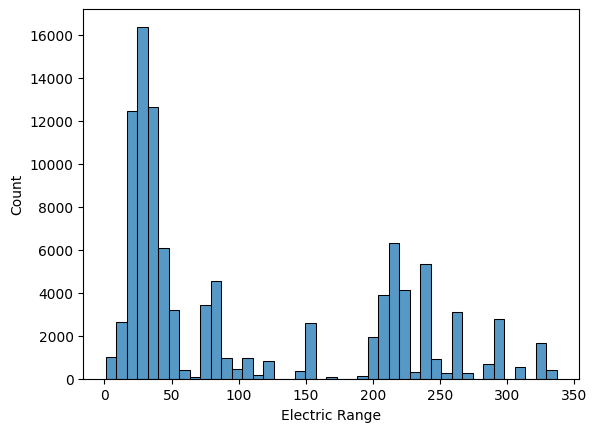

In [26]:
#Question: What is the distribution of Electric Range for these vehicles?
sns.histplot(df2['Electric Range'])
plt.show()

plt.style.use("seaborn-v0_8-darkgrid")

In [19]:
df2['Electric Range'].describe()

,Electric Range
count,101832.000000
mean,107.620227
std,97.197987
min,1.000000
25%,30.000000
50%,47.000000
75%,215.000000
max,337.000000


The data shows that the majority of electric vehicles have an electric range between 0 and 50 miles. The vehicle with the lowest range has a range of 1 mile(!!!) and the vehicle with the highest range has a range of 337 miles.
(NOTE: All the vehicles with an eletric range of 1 are Mercedes-Benz and they are are PHEVs)
The mean range is about 107 miles and the distriubution is very spread and heavily skewed to the left.

### b. Categorical Variable (Descriptive)


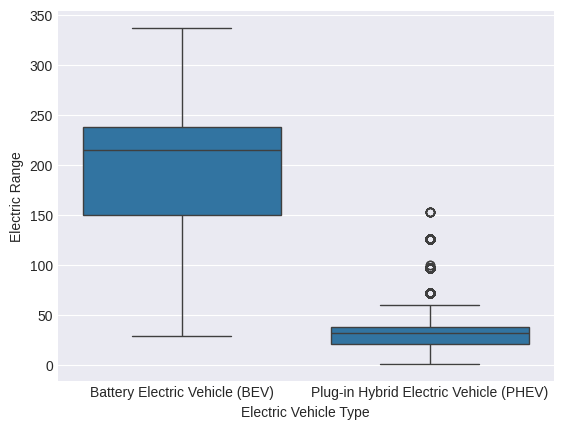

In [27]:
#Question: What electric vehicle type has the better electric range on average?
sns.boxplot(x="Electric Vehicle Type", y="Electric Range", data=df2)
plt.show()

In [14]:
df2[df2['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']['Electric Range'].describe()

,Electric Range
count,45947.000000
mean,199.931813
std,71.927325
min,29.000000
25%,150.000000
50%,215.000000
75%,238.000000
max,337.000000


In [17]:
df2[df2['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']['Electric Range'].describe()

,Electric Range
count,55885.000000
mean,31.724363
std,13.964509
min,1.000000
25%,21.000000
50%,32.000000
75%,38.000000
max,153.000000


From the plot and the summary, we can see that on average, the electric range for Battery Electric Vehicles (BEVs) are for greater than the Plug-in Hybrid Electric Vehicles (PHEVs). The median range for BEVs is around 220 miles, while the median for PHEVs is less than 50. Even the outliers for the PHEVs are all less than 200. The spread of Electric Range for the BEVs is from 29 to 337 miles while the spread for the PHEVs is from 1 to 153 miles.

### c. Relationship Between Variables (Exploratory)


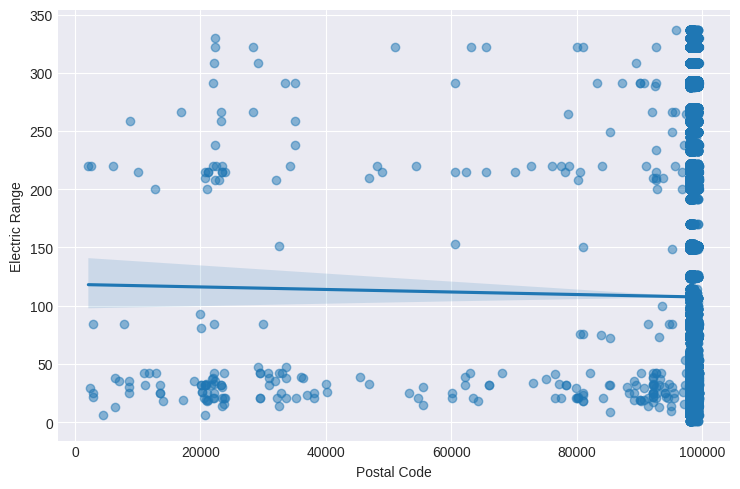

In [28]:
#Is there a relationship or an association between Electric Range and Postal Code?
sns.lmplot(x="Postal Code", y="Electric Range", data=df2, aspect=1.5, scatter_kws={'alpha':0.5})
plt.show()

As expected, the visualization shows that there is no relationship between electric range of the vehicles and the postal code. The data is very messy and scattered, and the linear regression line does not fall on any of the actual data. It is interesting to note that the majority of the data is clustered close to the 100000 postal code.

## 5. Conclusion


In summary, this project ended up focusing mostly on the electric range of the vehicles in the dataset, mainly because electric range was the only usable numerical column of data in this dataset. (That's why there wasn't a good option for the linear regression/relationship variable question). The biggest takeway from this project is the massive difference in electric range for BEVs vs PHEVs. Also, there is a lot of variation when it comes to the spread of electric range for both types of vehicles.

In the future, I'd like to see so more quantitative variables added to this dataset, for example, the price of the vehicles. That way there can be more exploration for relationships between variables.